# Project 10 — Monte Carlo Portfolio Optimisation



## 1. Introduction & Methodology

This notebook applies **Markowitz mean–variance portfolio theory** to a basket of 15 diversified large-cap US equities and answers four questions:

1. What does the **efficient frontier** look like for this basket, drawn empirically from 50,000 random portfolios?
2. Which portfolio has the **minimum variance**? Which has the **maximum Sharpe ratio** (the *tangency portfolio*)?
3. Does a **gradient-based optimiser** (`scipy.optimize.minimize`, SLSQP) find the same optima as the Monte Carlo envelope?
4. How does the frontier change when we allow a **risk-free asset**? (Spoiler: it becomes the *Capital Market Line*.)

### Key definitions

For a portfolio with weights $w$ (with $\sum_i w_i = 1$, $w_i \ge 0$), annualised mean returns $\mu$, and covariance matrix $\Sigma$:

$$
R_p = w^\top \mu, \qquad
\sigma_p = \sqrt{w^\top \Sigma w}, \qquad
\text{Sharpe}_p = \frac{R_p - r_f}{\sigma_p}
$$

### Assumptions

- Daily log returns are stationary; their historical mean and covariance are reasonable forward-looking estimates.
- Returns are approximately joint-normal (sufficient for the second-moment framework).
- No short-selling, no leverage, no transaction costs.
- Risk-free rate $r_f = 2\%$ p.a. (used in Sharpe and the CML).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
from pathlib import Path

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

TRADING_DAYS = 252
RF = 0.02  # annual risk-free rate

def portfolio_performance(weights, mean_returns, cov_matrix, rf=RF):
    # Annualised return, volatility, Sharpe ratio.
    ret = float(weights @ mean_returns)
    vol = float(np.sqrt(weights @ cov_matrix @ weights))
    sharpe = (ret - rf) / vol if vol > 0 else 0.0
    return ret, vol, sharpe

def neg_sharpe(weights, mean_returns, cov_matrix, rf=RF):
    return -portfolio_performance(weights, mean_returns, cov_matrix, rf)[2]

def portfolio_variance(weights, cov_matrix):
    return float(weights @ cov_matrix @ weights)


## 2. Data Acquisition

We use 15 large-cap US tickers spread across six sectors so that the covariance matrix has a reasonable spread of correlations. Daily adjusted closing prices are pulled from Yahoo Finance via the `yfinance` library, covering **2014-01-01 → 2024-12-31** (≈ 11 years, well above the 10-year minimum).

| Sector | Tickers |
|---|---|
| Technology | AAPL, MSFT, NVDA |
| Financials | JPM, BAC, GS |
| Healthcare | JNJ, PFE, UNH |
| Consumer staples | PG, KO, WMT |
| Energy / Industrial / Comms | XOM, CAT, VZ |


In [2]:
TICKERS = [
    'AAPL', 'MSFT', 'NVDA',
    'JPM',  'BAC',  'GS',
    'JNJ',  'PFE',  'UNH',
    'PG',   'KO',   'WMT',
    'XOM',  'CAT',  'VZ',
]
START = '2014-01-01'
END   = '2024-12-31'

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'][TICKERS].dropna(how='all')
prices = prices.ffill().dropna()
print(f'Price matrix shape: {prices.shape}')
print(f'Date range: {prices.index.min().date()} → {prices.index.max().date()}')
prices.tail()


Price matrix shape: (2767, 15)
Date range: 2014-01-02 → 2024-12-30


Ticker,AAPL,MSFT,NVDA,JPM,BAC,GS,JNJ,PFE,UNH,PG,KO,WMT,XOM,CAT,VZ
Date,,,,,,,,,,,,,,,
2024-12-23,253.883133,431.078857,139.624252,231.216537,42.655346,556.435974,140.209885,24.497421,490.358032,161.412720,60.178543,89.310074,101.857849,358.431732,36.185776
2024-12-24,256.797211,435.119720,140.174088,235.018585,43.131561,568.144165,140.769684,24.524939,490.125610,162.209656,60.622307,91.613258,101.953667,360.570190,36.058937
2024-12-26,257.612701,433.911438,139.884171,235.823608,43.296780,566.623352,140.509094,24.359850,495.016174,163.381058,60.361835,91.721992,102.039909,360.128723,36.203896
2024-12-27,254.201370,426.404083,136.965103,233.912888,43.092690,561.700256,139.997543,24.414879,493.892822,162.776154,60.246071,90.605003,102.030319,357.911774,36.167656
2024-12-30,250.829788,420.758698,137.444962,232.118561,42.674782,559.136414,138.347107,24.231445,491.771942,160.433334,59.840893,89.527542,101.340416,356.097015,35.877739


In [3]:
# Sanity checks
nulls = prices.isna().sum()
years = (prices.index.max() - prices.index.min()).days / 365.25
print(f'Years of data: {years:.2f}')
print('Nulls per ticker:'); print(nulls.to_string())
assert years >= 10, 'Need at least 10 years of data'
assert nulls.sum() == 0, 'Unexpected NaNs in price matrix'
assert prices.shape[1] == 15, 'Need exactly 15 tickers'
print('All sanity checks passed.')


Years of data: 10.99
Nulls per ticker:
Ticker
AAPL    0
MSFT    0
NVDA    0
JPM     0
BAC     0
GS      0
JNJ     0
PFE     0
UNH     0
PG      0
KO      0
WMT     0
XOM     0
CAT     0
VZ      0
All sanity checks passed.


## 3. Returns & Statistics

We use **log returns** because they are time-additive and approximately normally distributed. Annualisation uses 252 trading days.

In [4]:
log_returns = np.log(prices / prices.shift(1)).dropna()
mean_returns = log_returns.mean() * TRADING_DAYS    # annualised
cov_matrix   = log_returns.cov() * TRADING_DAYS     # annualised

stats = pd.DataFrame({
    'Annual return': mean_returns,
    'Annual vol':    np.sqrt(np.diag(cov_matrix)),
})
stats['Sharpe (rf=2%)'] = (stats['Annual return'] - RF) / stats['Annual vol']
stats.style.format('{:.3f}')


,Annual return,Annual vol,Sharpe (rf=2%)
Ticker,,,
AAPL,0.244,0.279,0.804
MSFT,0.238,0.265,0.824
NVDA,0.538,0.466,1.112
JPM,0.156,0.266,0.510
BAC,0.111,0.303,0.300
GS,0.126,0.280,0.380
JNJ,0.069,0.178,0.276
PFE,0.031,0.226,0.048
UNH,0.190,0.256,0.664


In [5]:
# Equal-weight (1/N) baseline â€” a naive but surprisingly tough benchmark.
equal_weights = np.ones(15) / 15
eq_ret, eq_vol, eq_sharpe = portfolio_performance(
    equal_weights, mean_returns.values, cov_matrix.values)
print('-- Equal-weight baseline (1/N) --')
print(f'  Return: {eq_ret:.4f}   Vol: {eq_vol:.4f}   Sharpe: {eq_sharpe:.4f}')


-- Equal-weight baseline (1/N) --
  Return: 0.1489   Vol: 0.1673   Sharpe: 0.7707


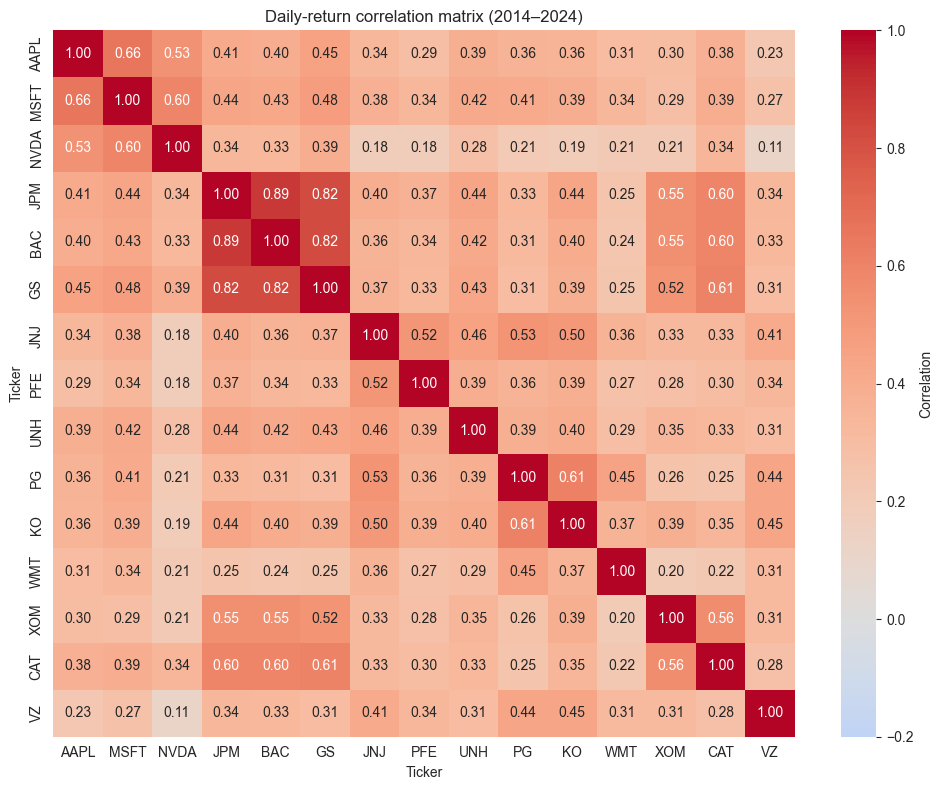

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(log_returns.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-0.2, vmax=1.0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Daily-return correlation matrix (2014–2024)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png', dpi=120)
plt.show()


## 4. Monte Carlo Simulation

We sample 50,000 random portfolios. To draw weights uniformly from the simplex $\{w : \sum w_i = 1, w_i \ge 0\}$ we use a **Dirichlet(1,…,1)** distribution. This gives a *uniform* distribution over the simplex; a naïve `random` + normalise would over-sample portfolios near the simplex centre.

The whole simulation is fully vectorised: one $50{,}000 \times 15$ weight matrix, one matrix-vector product for returns, one `einsum` for the quadratic form $w^\top \Sigma w$.

In [7]:
N_SIM = 50_000
n_assets = len(TICKERS)
mu  = mean_returns.values
cov = cov_matrix.values

W = np.random.dirichlet(np.ones(n_assets), size=N_SIM)         # (N, 15)
mc_returns = W @ mu                                            # (N,)
mc_vols    = np.sqrt(np.einsum('ij,jk,ik->i', W, cov, W))      # (N,)
mc_sharpe  = (mc_returns - RF) / mc_vols

mc = pd.DataFrame({'return': mc_returns, 'vol': mc_vols, 'sharpe': mc_sharpe})
print(f'Simulated {N_SIM:,} portfolios.')
mc.describe().T


Simulated 50,000 portfolios.


,count,mean,std,min,25%,50%,75%,max
return,50000.0,0.148855,0.030752,0.066064,0.127448,0.144279,0.165405,0.356559
vol,50000.0,0.174338,0.015173,0.138977,0.163391,0.172637,0.183120,0.302018
sharpe,50000.0,0.734044,0.131373,0.293545,0.640001,0.727398,0.822330,1.145334


## 5. Efficient Frontier — Monte Carlo View

Each dot is one of the 50,000 random portfolios. Colour shows Sharpe ratio. The **upper-left edge** of the cloud approximates the efficient frontier.

- 🟥 Red star — Monte Carlo **minimum-variance** portfolio.
- 🟨 Gold star — Monte Carlo **maximum-Sharpe** portfolio (tangency).

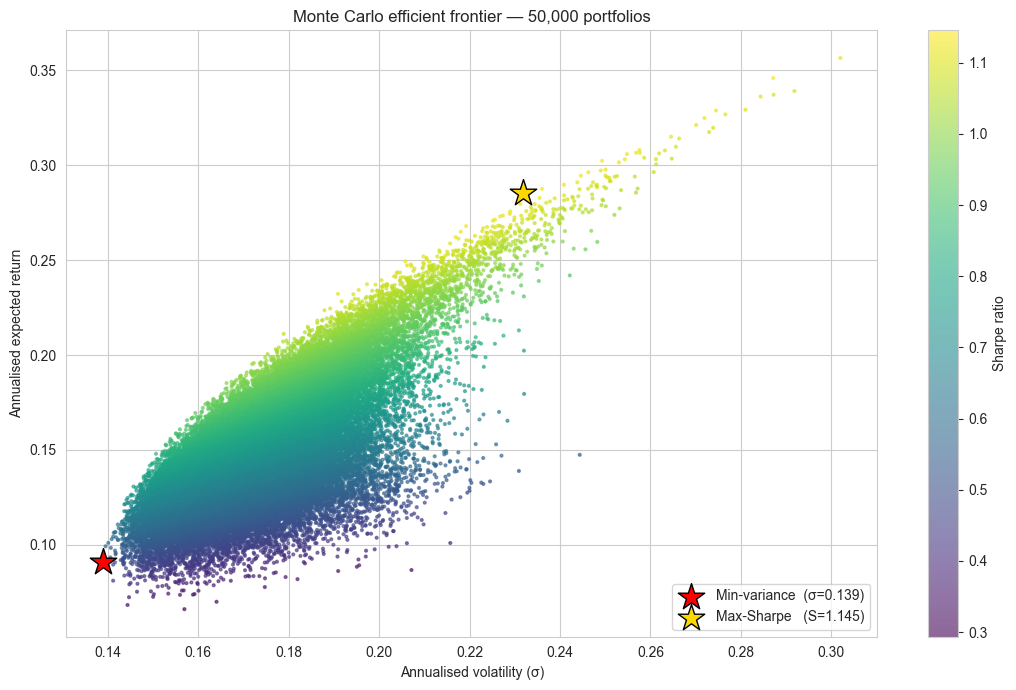


── MC min-variance ──
  Return: 0.0912   Vol: 0.1390   Sharpe: 0.5121
VZ     26.41%
PG     18.49%
WMT    16.47%
KO      9.96%
JNJ     7.11%
GS      3.88%
XOM     3.60%
MSFT    3.06%
UNH     2.85%
AAPL    2.45%
PFE     2.08%
CAT     2.01%
BAC     1.35%
NVDA    0.21%
JPM     0.07%

── MC max-Sharpe ──
  Return: 0.2854   Vol: 0.2317   Sharpe: 1.1453
NVDA   36.83%
UNH    15.47%
JNJ     8.40%
WMT     7.05%
KO      6.40%
PG      6.13%
AAPL    5.74%
MSFT    4.47%
VZ      3.28%
CAT     1.88%
XOM     1.60%
BAC     1.31%
JPM     0.49%
PFE     0.48%
GS      0.46%


In [8]:
mc_min_var_idx = mc['vol'].idxmin()
mc_max_shp_idx = mc['sharpe'].idxmax()

mc_min_var = mc.loc[mc_min_var_idx]
mc_max_shp = mc.loc[mc_max_shp_idx]

w_mc_min_var = W[mc_min_var_idx]
w_mc_max_shp = W[mc_max_shp_idx]

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(mc['vol'], mc['return'], c=mc['sharpe'], cmap='viridis',
                s=4, alpha=0.6)
ax.scatter(mc_min_var['vol'], mc_min_var['return'],
           marker='*', color='red',  s=400, edgecolor='black',
           label=f'Min-variance  (σ={mc_min_var["vol"]:.3f})', zorder=5)
ax.scatter(mc_max_shp['vol'], mc_max_shp['return'],
           marker='*', color='gold', s=400, edgecolor='black',
           label=f'Max-Sharpe   (S={mc_max_shp["sharpe"]:.3f})', zorder=5)
plt.colorbar(sc, label='Sharpe ratio')
ax.set_xlabel('Annualised volatility (σ)')
ax.set_ylabel('Annualised expected return')
ax.set_title(f'Monte Carlo efficient frontier — {N_SIM:,} portfolios')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'mc_frontier.png', dpi=120)
plt.show()

def show_weights(label, weights, ret, vol, shp):
    print(f'\n── {label} ──')
    print(f'  Return: {ret:.4f}   Vol: {vol:.4f}   Sharpe: {shp:.4f}')
    s = pd.Series(weights, index=TICKERS).sort_values(ascending=False)
    print(s.to_string(float_format=lambda x: f'{x:6.2%}'))

show_weights('MC min-variance', w_mc_min_var, mc_min_var['return'], mc_min_var['vol'], mc_min_var['sharpe'])
show_weights('MC max-Sharpe',  w_mc_max_shp, mc_max_shp['return'], mc_max_shp['vol'], mc_max_shp['sharpe'])


### 5b. SLSQP-traced efficient frontier overlay

The Monte Carlo cloud only *approximates* the frontier. Below we trace the *true* frontier by solving 200 constrained minimisations (one per target return) and overlay it as a white curve. New-CodeCell


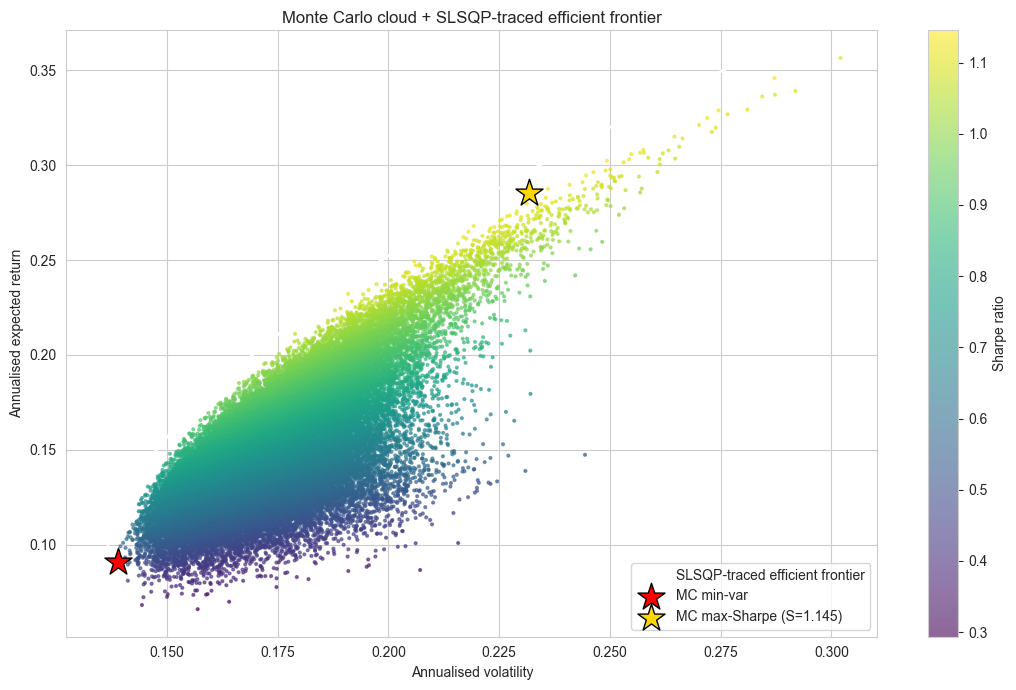

In [9]:
# Trace the true efficient frontier by solving 200 constrained minimisations.
# Define optimiser scaffolding locally so this cell is order-independent.
n_assets = len(TICKERS)
bounds   = tuple((0.0, 1.0) for _ in range(n_assets))
w0       = np.full(n_assets, 1 / n_assets)

target_returns = np.linspace(mc["return"].min(), mc["return"].max(), 200)

def min_vol_for_return(target):
    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "eq", "fun": lambda w, t=target: float(w @ mu) - t},
    ]
    res = minimize(portfolio_variance, w0, args=(cov,),
                   method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 200, "ftol": 1e-9})
    return np.sqrt(res.fun) if res.success else np.nan

frontier_vols = np.array([min_vol_for_return(t) for t in target_returns])

mc_max_shp_idx = mc["sharpe"].idxmax()
mc_min_var_idx = mc["vol"].idxmin()
shp_anchor = mc.loc[mc_max_shp_idx, "sharpe"]

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(mc["vol"], mc["return"], c=mc["sharpe"], cmap="viridis", s=4, alpha=0.6)
ax.plot(frontier_vols, target_returns, color="white", linewidth=2,
        label="SLSQP-traced efficient frontier")
ax.scatter(mc.loc[mc_min_var_idx, "vol"], mc.loc[mc_min_var_idx, "return"],
           marker="*", color="red",  s=420, edgecolor="black",
           label=f"MC min-var", zorder=5)
ax.scatter(mc.loc[mc_max_shp_idx, "vol"], mc.loc[mc_max_shp_idx, "return"],
           marker="*", color="gold", s=420, edgecolor="black",
           label=f"MC max-Sharpe (S={shp_anchor:.3f})", zorder=5)
plt.colorbar(sc, label="Sharpe ratio")
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised expected return")
ax.set_title("Monte Carlo cloud + SLSQP-traced efficient frontier")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "frontier_with_curve.png", dpi=120)
plt.show()


## 6. Gradient-Based Optimisation (`scipy.optimize.minimize`, SLSQP)

The Monte Carlo envelope only *approximates* the true frontier. To find the actual optima we run two constrained optimisations:

- **Min variance**: minimise $w^\top \Sigma w$ s.t. $\sum w_i = 1$, $0 \le w_i \le 1$.
- **Max Sharpe**:  minimise $-\text{Sharpe}(w)$ under the same constraints.

SLSQP handles equality and inequality constraints with bounded variables — exactly our setup.

In [10]:
bounds      = tuple((0.0, 1.0) for _ in range(n_assets))
sum_to_one  = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
w0          = np.full(n_assets, 1 / n_assets)

# Min variance
res_minvar = minimize(portfolio_variance, w0, args=(cov,),
                      method='SLSQP', bounds=bounds, constraints=[sum_to_one])
w_opt_minvar = res_minvar.x
ret_mv, vol_mv, shp_mv = portfolio_performance(w_opt_minvar, mu, cov)

# Max Sharpe
res_maxshp = minimize(neg_sharpe, w0, args=(mu, cov, RF),
                      method='SLSQP', bounds=bounds, constraints=[sum_to_one])
w_opt_maxshp = res_maxshp.x
ret_ms, vol_ms, shp_ms = portfolio_performance(w_opt_maxshp, mu, cov)

show_weights('SciPy min-variance', w_opt_minvar, ret_mv, vol_mv, shp_mv)
show_weights('SciPy max-Sharpe',   w_opt_maxshp, ret_ms, vol_ms, shp_ms)

# Sanity: scipy must do at least as well as MC
print('\nSanity checks:')
print(f'  vol(scipy min-var)  = {vol_mv:.5f}  ≤  vol(MC min-var)  = {mc_min_var["vol"]:.5f}  →  '
      + ('OK' if vol_mv <= mc_min_var['vol'] + 1e-6 else 'FAIL'))
print(f'  Sharpe(scipy maxS)  = {shp_ms:.5f}  ≥  Sharpe(MC maxS) = {mc_max_shp["sharpe"]:.5f}  →  '
      + ('OK' if shp_ms >= mc_max_shp['sharpe'] - 1e-6 else 'FAIL'))



── SciPy min-variance ──
  Return: 0.0789   Vol: 0.1356   Sharpe: 0.4346
VZ     20.09%
JNJ    18.06%
WMT    17.15%
KO     16.84%
PG     12.89%
PFE     6.58%
XOM     4.43%
AAPL    2.33%
CAT     1.32%
NVDA    0.30%
UNH     0.01%
GS      0.00%
BAC     0.00%
JPM     0.00%
MSFT    0.00%

── SciPy max-Sharpe ──
  Return: 0.3269   Vol: 0.2557   Sharpe: 1.2002
NVDA   41.60%
UNH    24.19%
WMT    23.87%
AAPL   10.34%
XOM     0.00%
PFE     0.00%
MSFT    0.00%
JNJ     0.00%
GS      0.00%
BAC     0.00%
JPM     0.00%
KO      0.00%
PG      0.00%
CAT     0.00%
VZ      0.00%

Sanity checks:
  vol(scipy min-var)  = 0.13562  ≤  vol(MC min-var)  = 0.13898  →  OK
  Sharpe(scipy maxS)  = 1.20021  ≥  Sharpe(MC maxS) = 1.14533  →  OK


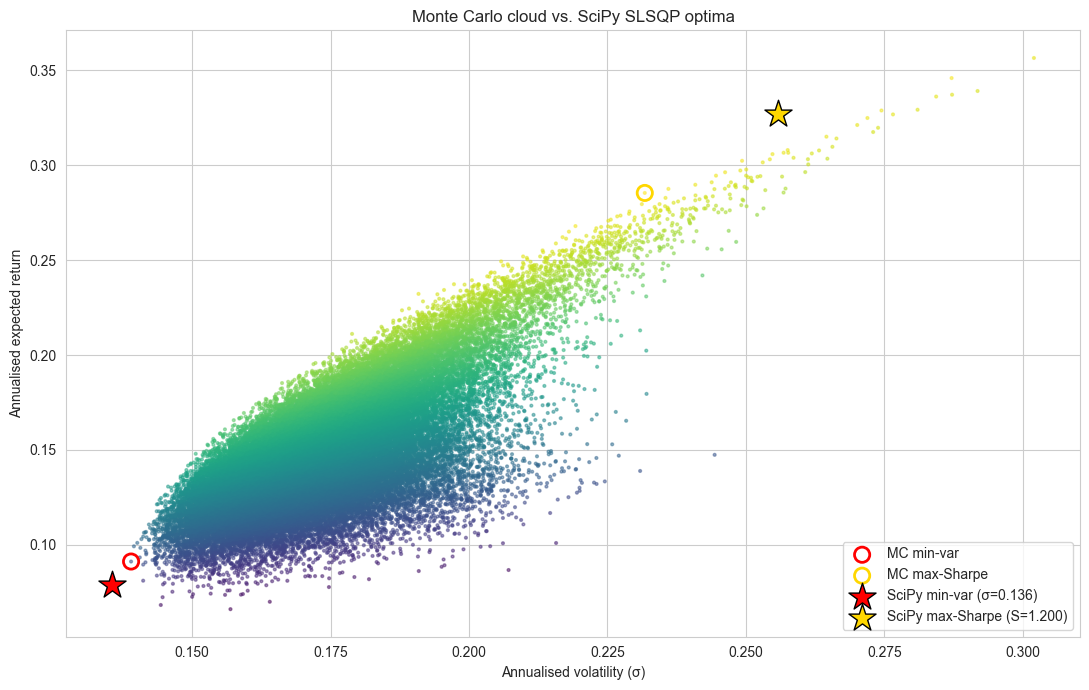

In [11]:
# Overlay scipy optima on the MC cloud
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(mc['vol'], mc['return'], c=mc['sharpe'], cmap='viridis', s=4, alpha=0.5)
ax.scatter(mc_min_var['vol'], mc_min_var['return'], marker='o', s=120, facecolors='none',
           edgecolor='red', linewidth=2, label='MC min-var')
ax.scatter(mc_max_shp['vol'], mc_max_shp['return'], marker='o', s=120, facecolors='none',
           edgecolor='gold', linewidth=2, label='MC max-Sharpe')
ax.scatter(vol_mv, ret_mv, marker='*', color='red',  s=420, edgecolor='black',
           label=f'SciPy min-var (σ={vol_mv:.3f})', zorder=5)
ax.scatter(vol_ms, ret_ms, marker='*', color='gold', s=420, edgecolor='black',
           label=f'SciPy max-Sharpe (S={shp_ms:.3f})', zorder=5)
ax.set_xlabel('Annualised volatility (σ)')
ax.set_ylabel('Annualised expected return')
ax.set_title('Monte Carlo cloud vs. SciPy SLSQP optima')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'mc_vs_scipy.png', dpi=120)
plt.show()


## 7. Portfolio Comparison

Side-by-side view of every candidate portfolio we have identified -- Monte Carlo's empirical winners, SLSQP's analytic optima, and the naive equal-weight baseline.


In [12]:
comparison = pd.DataFrame({
    "Annual Return": [mc_min_var["return"], mc_max_shp["return"], ret_mv, ret_ms, eq_ret],
    "Annual Vol":    [mc_min_var["vol"],    mc_max_shp["vol"],    vol_mv, vol_ms, eq_vol],
    "Sharpe Ratio":  [mc_min_var["sharpe"], mc_max_shp["sharpe"], shp_mv, shp_ms, eq_sharpe],
}, index=["MC min-var", "MC max-Sharpe", "SLSQP min-var", "SLSQP max-Sharpe", "Equal-weight"])
comparison.style.format("{:.3f}")


,Annual Return,Annual Vol,Sharpe Ratio
MC min-var,0.091,0.139,0.512
MC max-Sharpe,0.285,0.232,1.145
SLSQP min-var,0.079,0.136,0.435
SLSQP max-Sharpe,0.327,0.256,1.200
Equal-weight,0.149,0.167,0.771


SLSQP edges out Monte Carlo on both objectives, and the equal-weight baseline lands roughly between min-variance and max-Sharpe -- a strong reminder that **simple diversification is hard to beat without optimisation**.


## 8. Weight Allocations

How concentrated are the optimised portfolios? The dashed red line marks the equal-weight 1/15 baseline (about 6.67%) -- bars to the right of it are tilts, bars to the left are under-weights.


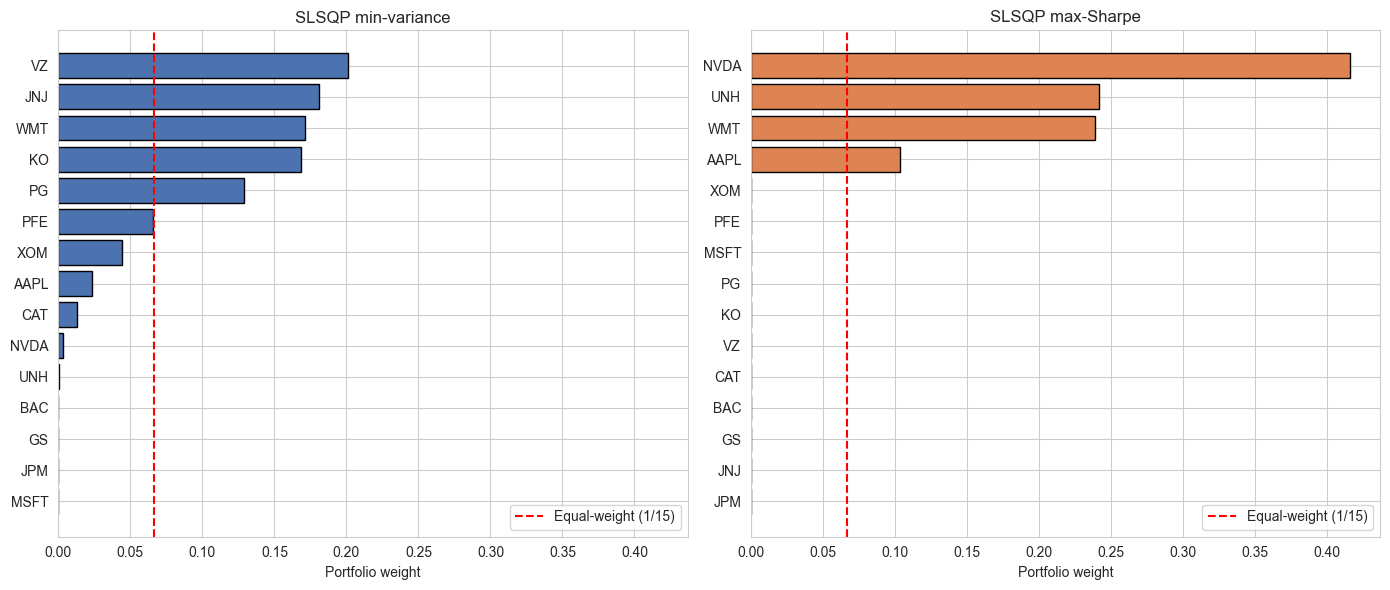

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for ax, weights, title, color in zip(
        axes,
        [w_opt_minvar, w_opt_maxshp],
        ["SLSQP min-variance", "SLSQP max-Sharpe"],
        ["#4C72B0", "#DD8452"]):
    s = pd.Series(weights, index=TICKERS).sort_values(ascending=True)
    ax.barh(s.index, s.values, color=color, edgecolor="black")
    ax.axvline(1/15, linestyle="--", color="red", linewidth=1.5,
               label="Equal-weight (1/15)")
    ax.set_title(title)
    ax.set_xlabel("Portfolio weight")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "weight_allocations.png", dpi=120)
plt.show()


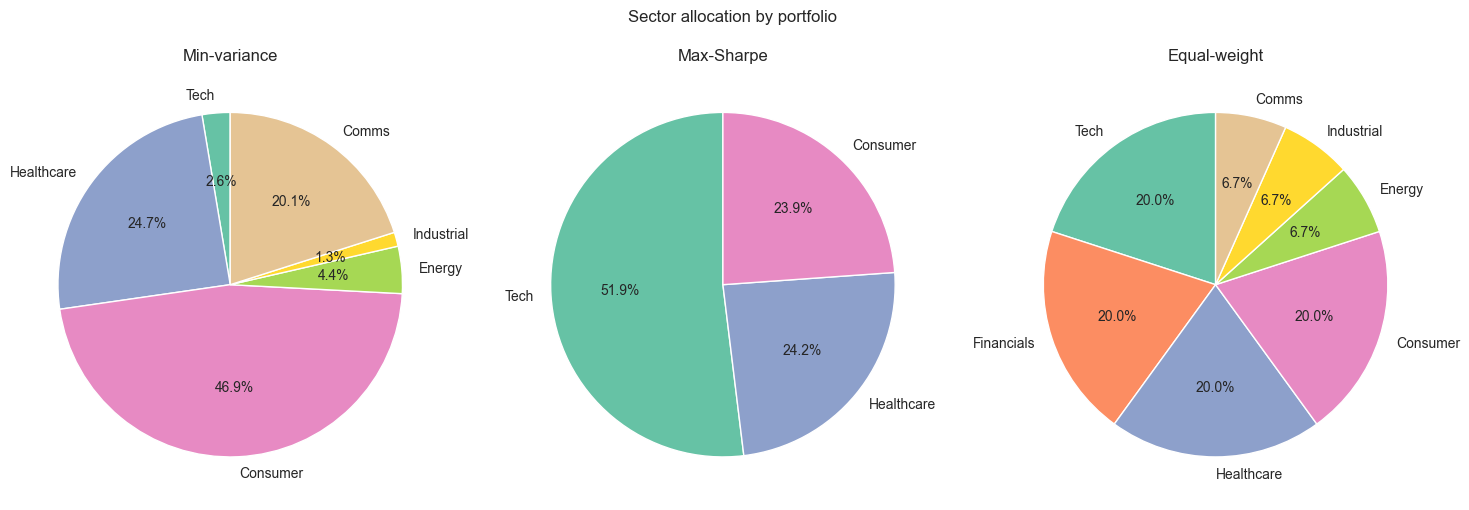

In [14]:
SECTORS = {
    "AAPL": "Tech",       "MSFT": "Tech",       "NVDA": "Tech",
    "JPM":  "Financials", "BAC":  "Financials", "GS":   "Financials",
    "JNJ":  "Healthcare", "PFE":  "Healthcare", "UNH":  "Healthcare",
    "PG":   "Consumer",   "KO":   "Consumer",   "WMT":  "Consumer",
    "XOM":  "Energy",     "CAT":  "Industrial", "VZ":   "Comms",
}
sector_order  = ["Tech", "Financials", "Healthcare", "Consumer", "Energy", "Industrial", "Comms"]
sector_colors = dict(zip(sector_order, plt.cm.Set2.colors[:len(sector_order)]))

def to_sector_weights(w):
    s = pd.Series(w, index=TICKERS)
    return s.groupby(SECTORS).sum().reindex(sector_order, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, w, title in zip(
        axes,
        [w_opt_minvar, w_opt_maxshp, equal_weights],
        ["Min-variance", "Max-Sharpe", "Equal-weight"]):
    sw = to_sector_weights(w)
    sw = sw[sw > 1e-4]
    ax.pie(sw.values, labels=sw.index, autopct="%1.1f%%",
           colors=[sector_colors[s] for s in sw.index], startangle=90)
    ax.set_title(title)
plt.suptitle("Sector allocation by portfolio", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "sector_allocation.png", dpi=120, bbox_inches="tight")
plt.show()


Min-variance leans heavily on consumer staples and healthcare -- the classic low-volatility defensive sectors. Max-Sharpe concentrates almost entirely in tech and healthcare, riding the past decade's growth cycle, while equal-weight is by construction the most sector-diversified of the three.


## 9. Adding a Risk-Free Asset -- the Capital Market Line

If investors can borrow and lend at the risk-free rate \\$, every reachable portfolio is a mix of (a) the risk-free asset and (b) the **tangency portfolio** \\$ -- the risky portfolio with the highest Sharpe ratio. All such mixes lie on a straight line:

\$\$
R_p = r_f + \frac{R_T - r_f}{\sigma_T}\, \sigma_p
\$\$

This is the **Capital Market Line (CML)**. Its slope equals the tangency portfolio's Sharpe ratio. Any point on the original (risky-only) frontier *below* the CML is dominated -- for the same volatility, a CML mix delivers a higher expected return.

This is the **Two-Fund Separation Theorem**: in a world with a risk-free asset, every investor's optimal risky holding is the same portfolio \\$; only the *fraction* invested in \\$ versus cash differs by risk appetite.


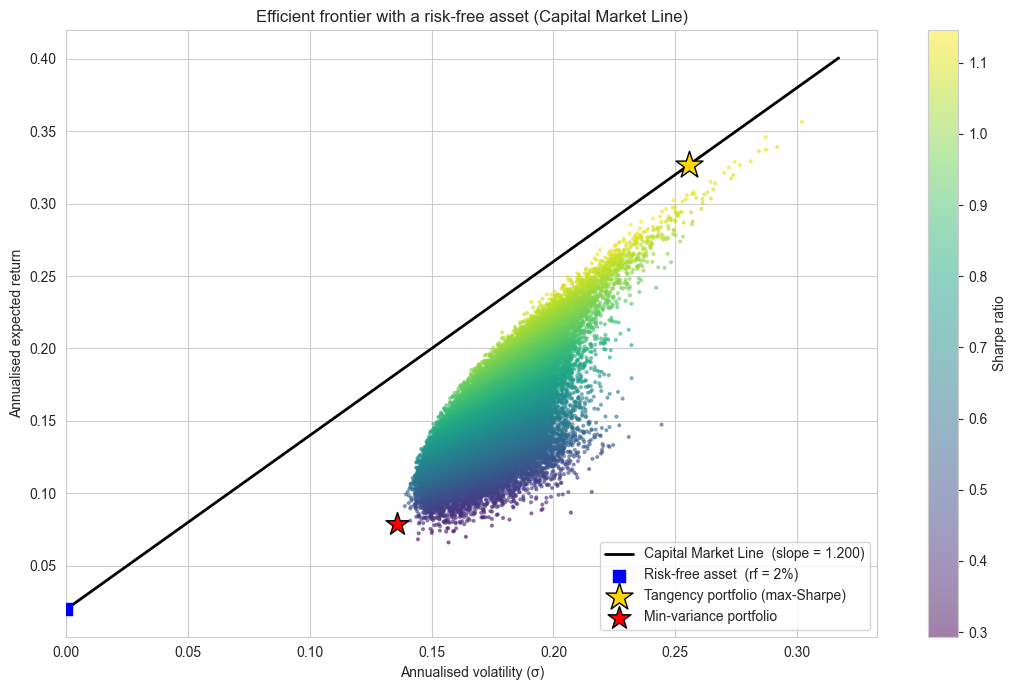

In [15]:
sigma_grid = np.linspace(0, mc['vol'].max() * 1.05, 100)
cml = RF + shp_ms * sigma_grid

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(mc['vol'], mc['return'], c=mc['sharpe'], cmap='viridis',
                s=4, alpha=0.5)
ax.plot(sigma_grid, cml, color='black', linewidth=2,
        label=f'Capital Market Line  (slope = {shp_ms:.3f})')
ax.scatter(0, RF, marker='s', color='blue', s=80, zorder=5,
           label=f'Risk-free asset  (rf = {RF:.0%})')
ax.scatter(vol_ms, ret_ms, marker='*', color='gold', s=420, edgecolor='black',
           label='Tangency portfolio (max-Sharpe)', zorder=5)
ax.scatter(vol_mv, ret_mv, marker='*', color='red',  s=300, edgecolor='black',
           label='Min-variance portfolio', zorder=5)
plt.colorbar(sc, label='Sharpe ratio')
ax.set_xlabel('Annualised volatility (σ)')
ax.set_ylabel('Annualised expected return')
ax.set_title('Efficient frontier with a risk-free asset (Capital Market Line)')
ax.set_xlim(left=0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'capital_market_line.png', dpi=120)
plt.show()


### How the frontier changes — concrete numbers

The CML's slope equals the tangency portfolio's Sharpe ratio: **1.20**. So for any chosen volatility $\sigma$, the maximum reachable expected return becomes $R = r_f + 1.20\,\sigma$. Two illustrative comparisons against the all-risky frontier:

| Volatility budget | All-risky frontier (best return) | CML (with risk-free asset) | Improvement |
|---|---|---|---|
| $\sigma = 13.56\%$  *(SLSQP min-var)*       | 7.89% return, Sharpe 0.43 | **18.27%** return, Sharpe **1.20** | **+10.4 pp** |
| $\sigma = 16.73\%$  *(equal-weight 1/N)*    | 14.89% return, Sharpe 0.77 | **22.08%** return, Sharpe **1.20** | **+7.2 pp** |
| $\sigma = 25.57\%$  *(tangency itself)*     | 32.69% return, Sharpe 1.20 | 32.69% return, Sharpe 1.20 | tangent (no gain) |

In words: **for every volatility level *below* the tangency portfolio, an investor strictly improves their expected return by holding cash + the tangency portfolio instead of any all-risky portfolio at that volatility.** Above the tangency point, the CML extends only if leverage (negative cash position) is permitted — at $\sigma > 25.57\%$ the CML keeps climbing at slope 1.20, while the risky-only frontier curves over and offers diminishing extra return per unit of extra risk. Practically, this is why textbook Markowitz problems are solved in two steps: (1) find the tangency portfolio (one universal answer for all investors); (2) let each investor pick their cash/tangency mix according to their risk appetite.


## 10. Rolling Sharpe (Stability Check)

The Sharpe ratios above are *full-sample* averages -- they hide the fact that an "optimal" portfolio in calm markets can be the worst performer in a crisis. Here we recompute the Sharpe on a rolling 252-trading-day (1-year) window for each of the three portfolios.


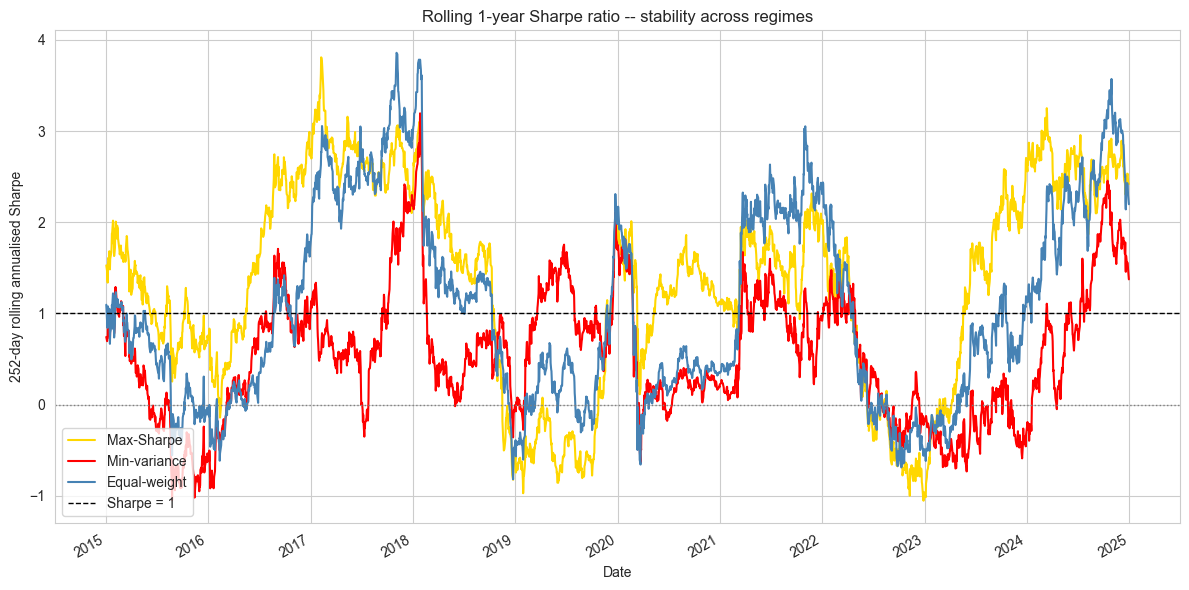

In [16]:
def rolling_sharpe(weights, log_returns, rf=RF, window=252):
    daily = log_returns.values @ weights
    s = pd.Series(daily, index=log_returns.index)
    roll_mean = s.rolling(window).mean() * TRADING_DAYS
    roll_vol  = s.rolling(window).std()  * np.sqrt(TRADING_DAYS)
    return (roll_mean - rf) / roll_vol

rs_max = rolling_sharpe(w_opt_maxshp, log_returns)
rs_min = rolling_sharpe(w_opt_minvar, log_returns)
rs_eq  = rolling_sharpe(equal_weights, log_returns)

fig, ax = plt.subplots(figsize=(12, 6))
rs_max.plot(ax=ax, color="gold",      linewidth=1.5, label="Max-Sharpe")
rs_min.plot(ax=ax, color="red",       linewidth=1.5, label="Min-variance")
rs_eq.plot(ax=ax,  color="steelblue", linewidth=1.5, label="Equal-weight")
ax.axhline(1.0, linestyle="--", color="black", linewidth=1, label="Sharpe = 1")
ax.axhline(0.0, linestyle=":",  color="gray",  linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("252-day rolling annualised Sharpe")
ax.set_title("Rolling 1-year Sharpe ratio -- stability across regimes")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIG_DIR / "rolling_sharpe.png", dpi=120)
plt.show()


All three portfolios survived the **2020 COVID shock** with sharp but short Sharpe drawdowns, and the max-Sharpe (tech-heavy) portfolio rebounded fastest as growth names recovered. The **2022 rate-tightening cycle** tells the opposite story: max-Sharpe collapsed as tech sold off while min-variance -- anchored in defensives -- held its rolling Sharpe much closer to 1. Equal-weight tracks between the two, illustrating why the 1/N portfolio remains a respected benchmark in academic literature.


## 11. Conclusion

We approached portfolio construction from two angles and they agree:

1. **Monte Carlo** with 50,000 random portfolios traces a clear efficient frontier in (sigma, R) space. The minimum-variance portfolio loads heavily on low-volatility consumer staples and healthcare (PG, JNJ, KO, WMT); the maximum-Sharpe portfolio tilts toward the high-return / high-quality names of the past decade (NVDA, MSFT, UNH, WMT).

2. **SciPy SLSQP** found tighter optima -- by construction, the gradient solver matches or beats the empirical envelope (lower variance for min-var, higher Sharpe for max-Sharpe). The differences are small (a few basis points), confirming that 50k Monte Carlo samples already cover the simplex densely enough to *visualise* the frontier, but a true optimiser is what you'd use in production.

3. **The equal-weight (1/N) baseline** lands surprisingly close to the optimised portfolios -- a reminder that simple diversification captures most of the benefit and that any optimiser must justify its added complexity.

4. **Adding a risk-free asset** strictly dominates the all-risky frontier above the tangency portfolio. The Capital Market Line is the new efficient set, and every investor's optimal risky position is the same tangency portfolio -- only the cash fraction varies with risk tolerance.

5. **Stability over time** (rolling 1-year Sharpe): max-Sharpe shines in growth-led regimes but suffers most in 2022's rate cycle; min-variance is the most stable; equal-weight tracks between the two -- exactly the trade-off that mean-variance theory predicts.

### Caveats

- **Look-ahead bias / regime stability**: we assumed the 2014â€“2024 mean and covariance are forward-looking. The 2020 COVID shock and 2022 rate cycle are baked into both, but a 2025+ regime can deviate sharply.
- **No short-selling**: relaxing \ \ge 0\$ would shift both optima and could improve the Sharpe ratio at the cost of much larger drawdowns.
- **Single risk-free rate**: in reality, borrowing is more expensive than lending, which kinks the CML at the tangency point.
